# Phase and Gain of Annual Harmonic versus mean local temperature
Below I show that over a wide range of climates, you see a robust decrease in the Gain (amplitude of surface temperature / amplitude of SW radiation) with warming. Also, the gradient appears to be approximately constant at all latitudes.

I first do this over a range of latitudes.

In [2]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff, get_temp_from_sphum_sat
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic, get_fit_coef_complex
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic, combine_olr_adv
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff, get_heat_cap_lambda_eff2

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [3]:
from time import perf_counter


def timed_step(label, func):
    """Run func(), print elapsed time, and return its result."""
    start = perf_counter()
    result = func()
    elapsed = perf_counter() - start
    print(f"{label:<55} {elapsed:8.2f} s")
    return result


In [4]:
# Get sigma for vertical integrals
# exp_dir = f'thesis_season/column/depth=2/tau_sweep/'
# exp_dir = f'tau_sweep/land/meridional_band/depth=1/bucket_evap/'
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
namelist = isca_tools.load_namelist(f"{exp_dir}/k=1")
sigma_levels_half = np.asarray(namelist['vert_coordinate_nml']['bk'])
sigma_levels_full = np.convolve(sigma_levels_half, np.ones(2) / 2, 'valid')
albedo = namelist['mixed_layer_nml']['albedo_value']
depth = namelist['mixed_layer_nml']['depth']
heat_cap_surf = get_heat_capacity(c_p_ocean, rho_ocean, depth)

In [5]:
use_sphum_col = False       # If atmospheric heat capacity is crucial then maybe would expect interesting relation to column sphum - x axis in plot
odp_vals = [0.6, 0.8, 1, 1.5, 2, 2.5, 3, 3.5]
n_exp = len(odp_vals)
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
vars_keep = ['t_surf', 'swdn_sfc']
if use_sphum_col:
    vars_keep += ['sphum', 'ps']
lat_min = 30
lat_max = 90
ds_base = []
for i, val in tqdm(enumerate(odp_vals), total=n_exp):
    path_use = os.path.join(exp_dir, f"k={str(val).replace('.','_')}")
    ds_use = isca_tools.load_dataset(path_use, first_month_file=2 if 'column' in exp_dir else 25).sel(lat=slice(lat_min, lat_max))[vars_keep]
    if use_sphum_col:
        if not isinstance(sigma_levels_full, xr.DataArray):
            sigma_levels_full = (ds_use.pfull*0+sigma_levels_full).squeeze()
        ds_use['sphum_col'] = mass_weighted_vertical_integral(ds_use.sphum, ds_use.ps*sigma_levels_full, 'pfull', simpson_method=False)
    ds_base.append(ds_use.load())
odp_vals_xr = xr.DataArray(odp_vals, dims="odp", name='odp')
ds_base = xr.concat(ds_base, dim=odp_vals_xr).squeeze()
if 'land' in exp_dir:
    ds_base = ds_base.sel(lon=slice(150, 210))
if 'column' in exp_dir:
    ds_base = ds_base.expand_dims({'lon': [0]})     #  so next line works
ds = utils.get_annual_zonal_mean(ds_base)  # also smooths by 50 days
ds.attrs['depth'] = int(re.search(r"depth=(\d+)", exp_dir).group(1))
ds.attrs['heat_capacity'] = get_heat_capacity(c_p_ocean, rho_ocean, ds.depth)

  0%|          | 0/8 [00:00<?, ?it/s]

In [6]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.t_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
ds['coef_sw_amp'] = np.abs(coef_sw_amp.sel(harmonic=1))
ds['coef_amp'] = np.abs(coef_amp.sel(harmonic=1))
ds['coef_phase'] = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
ds['heat_cap_multiplier'] = get_heat_capacity(c_p_ocean, rho_ocean,
                                        ds.coef_sw_amp * np.sin(ds.coef_phase) / (2 * np.pi * f) / ds.coef_amp,
                                        True) / ds.depth
ds['heat_capacity_eff'] = ds.heat_capacity * ds.heat_cap_multiplier
ds['lambda_eff'] = ds.coef_sw_amp * np.cos(ds.coef_phase) / ds.coef_amp

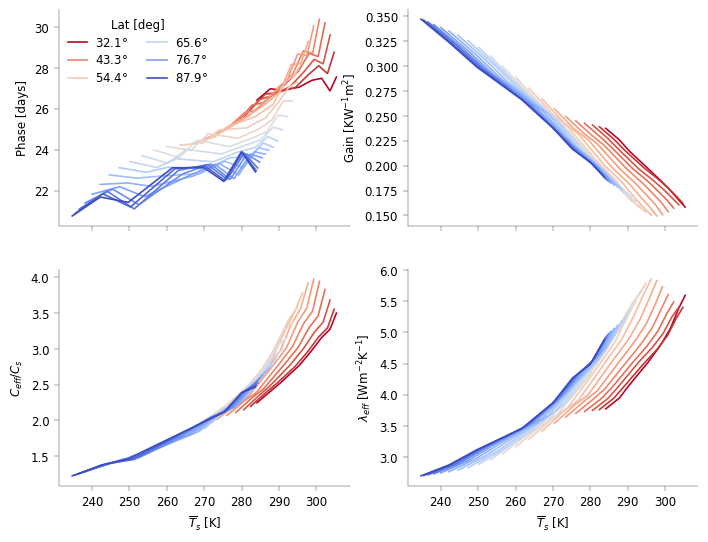

In [7]:
shift_lines = False         # So all cross through the origin, so can see gradient
color_lat = plt.colormaps["coolwarm_r"](np.linspace(0, 1, ds.lat.size))
fig, ax = plt.subplots(2, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
for i in range(0, ds.lat.size):
    ds_use = ds.isel(lat=i)
    var = ds_use.t_surf.mean(dim='time')
    if use_sphum_col:
        var = ds_use.sphum_col.mean(dim='time')*1000
    if shift_lines:
        var = var-var.mean(dim='odp')
    var2 = [ds_use.coef_phase / omega / utils.day_seconds, ds_use.coef_amp/ds_use.coef_sw_amp,
            ds_use.heat_cap_multiplier, ds_use.lambda_eff]
    for j in range(len(var2)):
        ax[j].plot(var, var2[j] - var2[j].mean(dim='odp') if shift_lines else var2[j],
                   label=f"{ds_use.lat:.1f}$\degree$" if i%4==0 else None, color=color_lat[i])
ax[0].set_ylabel('Phase [days]')
ax[1].set_ylabel('Gain [KW$^{-1}$m$^2$]')
ax[2].set_ylabel('$C_{eff}/C_s$')
ax[3].set_ylabel('$\\lambda_{eff}$ [Wm$^{-2}$K$^{-1}$]')
if use_sphum_col:
    ax[2].set_xlabel('$\overline{q}_{col}$ [g/kg]')
    ax[3].set_xlabel('$\overline{q}_{col}$ [g/kg]')
else:
    ax[2].set_xlabel('$\overline{T}_s$ [K]')
    ax[3].set_xlabel('$\overline{T}_s$ [K]')
update_linewidth(fig)
ax[0].legend(ncol=2, title='Lat [deg]')
update_fontsize(fig, 7.2)
plt.show()

## Single Latitude
Now I look in more detail at a single latitude.

In [8]:
test = True     # only a few experiments
lat_sl = 40
vars_keep_sl = ['temp', 'ps', 'sphum', 'olr', 'swdn_toa', 'swdn_sfc', 'lwdn_sfc', 'lwup_sfc', 'flux_t',
                'flux_lhe', 't_surf']
ds_base_sl = []
if test:
    n_exp_sl = 3
    odp_slice = np.arange(3)
else:
    n_exp_sl = n_exp
    odp_slice = np.arange(n_exp)
for i, val in tqdm(enumerate(np.asarray(odp_vals, dtype=object)[odp_slice]), total=n_exp_sl):
    path_use = os.path.join(exp_dir, f"k={str(val).replace('.','_')}")
    ds_use = isca_tools.load_dataset(path_use, first_month_file=2 if 'column' in exp_dir else 25).sel(lat=lat_sl, method='nearest')[vars_keep_sl]
    ds_base_sl.append(ds_use.load())
ds_base_sl = xr.concat(ds_base_sl, dim=odp_vals_xr[odp_slice]).squeeze()

  0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
if not isinstance(sigma_levels_full, xr.DataArray):
    sigma_levels_full = (ds_base_sl.pfull*0+sigma_levels_full).squeeze()

# Get optical depth at surface
odp_info = {'ir_tau_eq': 6, 'ir_tau_pole': 1.5, 'linear_tau': 0.1, 'wv_exponent': 4}  # default vals
for key in odp_info:  # If provided, update
    if key in namelist['two_stream_gray_rad_nml']:
        odp_info[key] = namelist['two_stream_gray_rad_nml'][key]
ds_base_sl['odp_surf'] = utils.opd_lw_gray(ds_base_sl.lat, kappa=ds_base_sl.odp, tau_eq=odp_info['ir_tau_eq'],
                             tau_pole=odp_info['ir_tau_pole'], frac_linear=odp_info['linear_tau'],
                             k_exponent=odp_info['wv_exponent'])  # optical depth as function of latitude

In [10]:
# Get radiative temperatures
ds_base_sl['temp_rad_surf'] = utils.get_temp_rad_surf(ds_base_sl.lwdn_sfc, ds_base_sl.odp_surf)
ds_base_sl['temp_rad_atm'] = utils.get_temp_rad_atm(ds_base_sl.olr, ds_base_sl.t_surf, ds_base_sl.odp_surf)

# Get column quantities - very important to use simpson integral method
ds_base_sl['temp_col'] = mass_weighted_vertical_integral(ds_base_sl.temp, ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)
ds_base_sl['sphum_col'] = mass_weighted_vertical_integral(ds_base_sl.sphum, ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)
ds_base_sl['rh_col'] = ds_base_sl['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base_sl.temp, ds_base_sl.ps * sigma_levels_full),
                                                                                 ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)

In [22]:
# Get zonal annual mean dataset
ds_sl = utils.get_annual_zonal_mean(ds_base_sl.sel(pfull=np.inf, method='nearest'))
ds_sl['p_eff'] = get_p_eff(ds_sl.ps.mean(dim='time'))
ds_sl['temp_col_sphum'] = utils.get_temp_from_sphum_sat_xr(ds_sl.sphum_col / ds_sl.rh_col, ds_sl.p_eff)
ds_sl = ds_sl.rename_vars({'temp': 'temp_atm', 't_surf': 'temp_surf', 'ps': 'p_surf', 'sphum': 'q_atm'})
ds_sl['p_atm'] = ds_sl.p_surf * sigma_levels_full.sel(pfull=np.inf, method='nearest')
ds_sl['rh_atm'] = ds_sl.q_atm / sphum_sat(ds_sl.temp_atm, ds_sl.p_atm)

# Compute absoption coefficient explicitly from the amplitude of 1st harmonic of surface and toa sw fluxes
# Note that this will not work for the mean but that is not what we are interested in here.
ds_sl['sw_abs'] = utils.get_sw_abs_amp_xr(ds_sl.swdn_sfc, ds_sl.swdn_toa, ds_sl.time, albedo=albedo)
# # The actual expression below would be a function of time
# ds_sl['sw_abs'] = utils.get_frierson_sw_abs(namelist['two_stream_gray_rad_nml']['atm_abs'], ds_sl.p_surf)

In [12]:
# Get the contribution due to advection i.e., the convergence term on RHS of energy budget
p_calc = ds_sl.p_surf*(sigma_levels_full[-1]-sigma_levels_full[0])          # bounds of the integration

# Two methods for mse tend, prefer second as more directly related to the decomposition
# ds_sl['mse_tend'] = utils.spline_deriv_periodic_xr(ds_sl.time*utils.day_seconds, (c_p*ds_sl.temp_col + L_v*ds_sl.sphum_col) * p_calc/g)
ds_sl['mse_tend'] = utils.spline_deriv_periodic_xr(ds_sl.time*utils.day_seconds,
                                             (c_p*ds_sl.temp_col + L_v*ds_sl.rh_col*sphum_sat(ds_sl.temp_col_sphum, ds_sl.p_eff)) * p_calc/g)

ds_sl['flux_rhs'] = frierson_atmospheric_heating(ds_sl, albedo) + ds_sl.flux_t + ds_sl.flux_lhe
ds_sl['adv_total'] = ds_sl['mse_tend'] - ds_sl['flux_rhs']

### Check Atmospheric Energy Budget
This is closed by definition with advection, but for single column it serves as a sanity check.

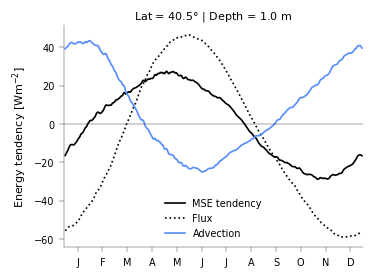

In [13]:
ind_use = 0
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
ax.plot(ds_sl.time, ds_sl['mse_tend'].isel(odp=ind_use), color='k', label='MSE tendency')
ax.plot(ds_sl.time, ds_sl['flux_rhs'].isel(odp=ind_use), color='k', label='Flux', linestyle=':')
if 'column' not in exp_dir:
    ax.plot(ds_sl.time, ds_sl['adv_total'].isel(odp=ind_use), color='C0', label='Advection')
else:
    print(f"Max error = {np.abs(ds_sl['adv_total'].isel(odp=ind_use)).max():.2f} W/m2")
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.legend()
ax.set_title(f'Lat = {ds_sl.lat.values:.1f}$\degree$ | Depth = {depth} m', y=0.99)
plt.show()

In [14]:
_, coef_amp_sl, coef_phase_sl = get_fourier_fit_xr(ds_sl.time, ds_sl.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp_sl, _ = get_fourier_fit_xr(ds_sl.time, ds_sl.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
ds_sl['coef_sw_amp'] = np.abs(coef_sw_amp_sl.sel(harmonic=1))
ds_sl['coef_amp'] = np.abs(coef_amp_sl.sel(harmonic=1))
ds_sl['coef_phase'] = coef_phase_sl.sel(harmonic=1)

coef_temp = {'amp': {}, 'phase': {}}
for key in ['col', 'col_sphum', 'rad_atm', 'rad_surf']:
    coef_temp['amp'][key], coef_temp['phase'][key] = utils.get_fit_coef_complex_xr(ds_sl[f"temp_{key}"], ds_sl.temp_atm, ds_sl.time)

In [15]:
# Get empirical feedback parameters
feedback_params = {'empirical': {}, 'analytic': {}}
# Account for pressure variation within the column throughout the year
feedback_params['empirical']['mu'] = utils.fit_linear_zero_mean_xr(utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds, ds_sl.temp_atm),
                                                  utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds,
                                                                  ds_sl.sphum_col * p_calc)) * L_v / c_p / p_calc.mean(dim='time')
# Old method neglecting pressure variation
feedback_params['empirical']['mu0'] = utils.fit_linear_zero_mean_xr(utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds, ds_sl.temp_atm),
                                                  utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds,
                                                                  ds_sl.sphum_col)) * L_v / c_p
lambda_lh_cont, feedback_params['empirical']['lambda_lh'] = utils.fit_linear_zero_mean_xr(ds_sl.temp_surf - ds_sl.temp_atm, ds_sl.flux_lhe,
                                                                         ds_sl.temp_atm)
lambda_sh_cont, feedback_params['empirical']['lambda_sh'] = utils.fit_linear_zero_mean_xr(ds_sl.temp_surf - ds_sl.temp_atm, ds_sl.flux_t,
                                                                         -ds_sl.temp_atm)
lambda_lw_cont, feedback_params['empirical']['lambda_lw2'] = utils.fit_linear_zero_mean_xr(ds_sl.temp_surf - ds_sl.temp_atm,
                                                                          ds_sl.lwup_sfc - ds_sl.lwdn_sfc, ds_sl.temp_atm)
feedback_params['empirical']['lambda_const'] = lambda_lh_cont + lambda_sh_cont + lambda_lw_cont
olr_surf_cont = Stefan_Boltzmann * np.exp(-ds_sl.odp_surf) * ds_sl.temp_surf ** 4
feedback_params['empirical']['lambda_lw1'] = utils.fit_linear_zero_mean_xr(ds_sl.temp_surf, olr_surf_cont)
feedback_params['empirical']['B'], feedback_params['empirical']['coef_phase_olr'] = \
    utils.get_fit_coef_complex_xr(ds_sl.olr - olr_surf_cont, ds_sl.temp_atm, ds_sl.time)
# Account for pressure variation within the column throughout the year
feedback_params['empirical']['coef_amp_col'], feedback_params['empirical']['coef_phase_col'] = \
    utils.get_fit_coef_complex_xr(utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds, ds_sl.temp_col * p_calc),
                               utils.spline_deriv_periodic_xr(ds_sl.time * utils.day_seconds, ds_sl.temp_atm), ds_sl.time)
feedback_params['empirical']['coef_amp_col'] /= p_calc.mean(dim='time')
# Old method neglecting pressure variation
feedback_params['empirical']['coef_amp_col0'] = coef_temp['amp']['col']
feedback_params['empirical']['coef_phase_col0'] = coef_temp['phase']['col']
feedback_params['empirical']['lambda_adv'], feedback_params['empirical']['coef_phase_adv'] = \
    utils.get_fit_coef_complex_xr(ds_sl.adv_total, -ds_sl.temp_atm, ds_sl.time)

In [16]:
get_var_shift_xr = wrap_with_apply_ufunc(get_var_shift, input_core_dims=[['time'], [], [], ['time']],
                                         output_core_dims=[['time']])

def get_approx_mse_tend(temp_atm, coef_amp_col, coef_phase_col, mu, p_calc, time=ds_sl.time):
    temp_atm_deriv = utils.spline_deriv_periodic_xr(time * utils.day_seconds, temp_atm)
    temp_atm_deriv_shift = get_var_shift_xr(temp_atm_deriv, coef_phase_col / (2 * np.pi / time.size),
                                            None, time)
    temp_col_tend = coef_amp_col * temp_atm_deriv_shift
    sphum_tend = mu * temp_atm_deriv
    c_a = c_p * p_calc / g
    return c_a * (temp_col_tend + sphum_tend)

def get_approx_flux_rhs(temp_atm, temp_surf, swdn_toa, sw_abs, lambda_const, lambda_resid, B, lambda_lw1,
                        coef_phase_olr):
    temp_atm = temp_atm - temp_atm.mean(dim='time')
    temp_surf = temp_surf - temp_surf.mean(dim='time')
    flux_abs = sw_abs * (swdn_toa - swdn_toa.mean(dim='time'))

    flux_linear = lambda_const * (temp_surf - temp_atm) + lambda_resid * temp_atm - lambda_lw1 * temp_surf
    temp_atm_shift = get_var_shift_xr(temp_atm, coef_phase_olr / (2 * np.pi / temp_atm.time.size),
                                      None, temp_atm.time)
    flux_shift = -B * temp_atm_shift
    return flux_abs + flux_linear + flux_shift

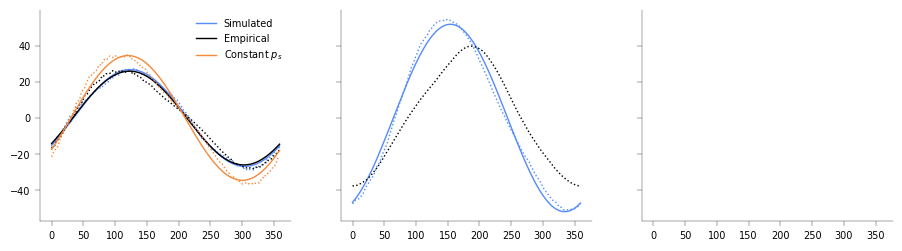

In [21]:
ind_use = 0
ds_use = ds_sl.isel(odp=ind_use)
param_use = {key: feedback_params['empirical'][key].isel(odp=ind_use) for key in feedback_params['empirical'].keys()}
param_use['p_calc'] = p_calc.isel(odp=ind_use).mean(dim='time')
param_use['lambda_resid'] = param_use['lambda_lh'] + param_use['lambda_lw2'] - param_use['lambda_sh']

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 2)
# MSE tendency on RHS
ax[0].plot(ds_sl.time, ds_use['mse_tend'], color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, ds_use['mse_tend'], n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds_sl.time, var, color='C0', label='Simulated')
var = get_approx_mse_tend(ds_use.temp_atm, param_use['coef_amp_col'], param_use['coef_phase_col'],
                          param_use['mu'], p_calc.isel(odp=ind_use))
ax[0].plot(ds_sl.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds_sl.time, var, color='k', label='Empirical')
# Also show the constant pressure version
var = get_approx_mse_tend(ds_use.temp_atm, param_use['coef_amp_col0'], param_use['coef_phase_col0'],
                          param_use['mu0'], param_use['p_calc'])
ax[0].plot(ds_sl.time, var, color='C1', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds_sl.time, var, color='C1', label='Constant $p_s$')

var = ds_use['flux_rhs']-ds_use['flux_rhs'].mean(dim='time')
ax[1].plot(ds_sl.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds_sl.time, var, color='C0')

var = get_approx_flux_rhs(ds_use.temp_atm, ds_use.temp_surf, ds_use.swdn_toa, ds_use.sw_abs, param_use['lambda_const'],
                          param_use['lambda_resid'], param_use['B'], param_use['lambda_lw1'],
                          param_use['coef_phase_olr'])
ax[1].plot(ds_sl.time, var, color='k', linestyle=':')
# var = spline_deriv_periodic_xr(ds_use.time*utils.day_seconds,
#                                              (c_p*ds_use.temp_col + L_v*ds_use.sphum_col
#                                               ) * param_use['p_calc']/g)
# ax[0].plot(ds_sl.time, var, color='k')
# var = spline_deriv_periodic_xr(ds_use.time*utils.day_seconds,
#                                              (c_p*ds_use.temp_col + L_v*ds_use.sphum_col
#                                               ) * p_calc.isel(odp=ind_use)/g)
# ax[0].plot(ds_sl.time, var, color='k', linestyle=':')
# var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
# if 'column' not in exp_dir:
#     ax.plot(ds_sl.time, ds_sl['adv_total'].isel(odp=ind_use), color='C0', label='Advection')
# else:
#     print(f"Max error = {np.abs(ds_sl['adv_total'].isel(odp=ind_use)).max():.2f} W/m2")
# update_linewidth(fig)
# ax.axhline(0, color='k', lw=ax_linewidth)
# ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
# ax.set_xlim(-1, 360)
# ax.set_xticks(*utils.month_ticks)
# ax.legend()
# ax.set_title(f'Lat = {ds_sl.lat.values:.1f}$\degree$ | Depth = {depth} m', y=0.99)
update_linewidth(fig)
ax[0].legend()
plt.show()

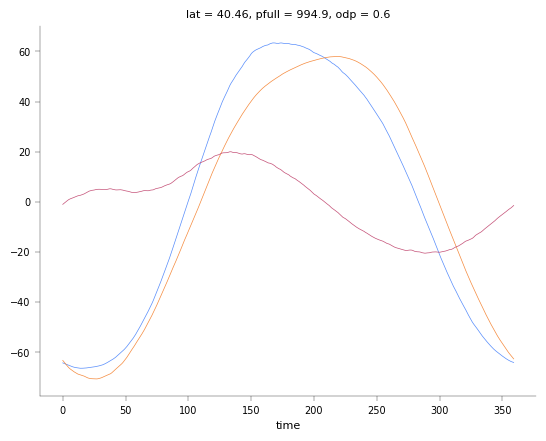

In [18]:
# var = (ds_use.lwup_sfc - ds_use.lwdn_sfc)
# (var-var.mean(dim='time')).plot()
var = ds_use.flux_lhe
(var-var.mean(dim='time')).plot()
# var = ds_use.flux_t
# (var-var.mean(dim='time')).plot()
var = lambda_lh_cont.isel(odp=ind_use) * (ds_use.temp_surf - ds_use.temp_atm) + param_use['lambda_lh'] * ds_use.temp_atm
(var-var.mean(dim='time')).plot()
var2 = ds_use.flux_lhe - var
(var2-var2.mean(dim='time')).plot()

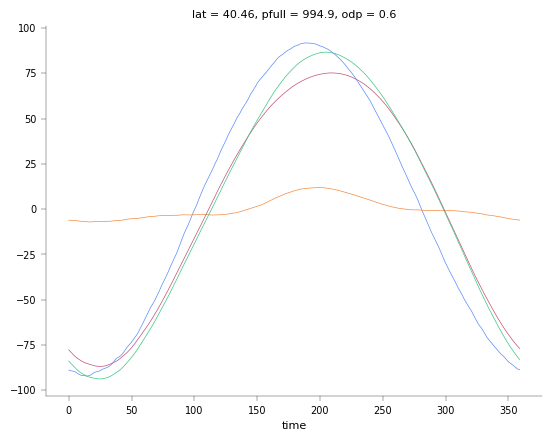

In [20]:
var = ds_use.flux_lhe+ds_use.flux_t+ds_use.lwup_sfc - ds_use.lwdn_sfc
(var - var.mean(dim='time')).plot()
var = param_use['lambda_const'] * (ds_use.temp_surf-ds_use.temp_atm)
(var-var.mean(dim='time')).plot()
var = param_use['lambda_resid'] * ds_use.temp_atm
(var-var.mean(dim='time')).plot()
var = param_use['lambda_const'] * (ds_use.temp_surf-ds_use.temp_atm) + param_use['lambda_resid'] * ds_use.temp_atm
(var-var.mean(dim='time')).plot()

In [23]:
def get_theory_quantities(feedback_params_dict, heat_cap_surf=heat_cap_surf, albedo=albedo, sw_abs=ds_sl.sw_abs,
                          pressure_heat_cap_atmos_calc=p_calc.mean(dim='time'),
                          omega=omega, coef_sw_amp=ds_sl['coef_sw_amp'], method=1, keep_adv=True,
                          small_phase=False):
    """Computes the four theoretical quantities from a set of feedback parameters.

    Given a dictionary of feedback parameters, this calls `get_heat_cap_lambda_eff`
    and combines the outputs with dataset/argument info to return the four
    quantities of interest.

    Args:
        feedback_params_dict (dict): Dictionary of feedback parameters, e.g.
            a single entry of `feedback_params[params_use]`, containing keys
            such as `mu`, `lambda_const`, `B`, `lambda_sh`, `lambda_lh`,
            `lambda_lw1`, `lambda_lw2`, `coef_amp_col`, `coef_phase_col`,
            `coef_phase_olr`.
        ds: Dataset containing `heat_capacity`, `albedo`, `sw_abs`.
        pressure_heat_cap_atmos_calc:
        omega (float): Angular frequency of forcing, $\omega$.
        coef_sw_amp (float): Amplitude coefficient of shortwave forcing.

    Returns:
        tuple: `(lambda_s1_eff, heat_cap_mult, coef_phase, coef_amp)`.
    """
    if (not keep_adv) or (method == 1):
        # remove advection terms
        feedback_params_dict = feedback_params_dict.copy()      # so deleting does not affect outside func
        del feedback_params_dict['lambda_adv']
        del feedback_params_dict['coef_phase_adv']
    if method == 1:
        # Old method with no advection
        lambda_mult, heat_cap_mult = get_heat_cap_lambda_eff(
            **feedback_params_dict, heat_cap_surf=heat_cap_surf,
            pressure_heat_cap_atmos_calc=pressure_heat_cap_atmos_calc,
            albedo=albedo, sw_abs=sw_abs
        )
        lambda_eff = feedback_params_dict['lambda_const'] * lambda_mult
        heat_cap_eff = heat_cap_surf * heat_cap_mult
    else:
        # Nw method which includes advection, and all dimensionless
        lambda_eff, heat_cap_eff = get_heat_cap_lambda_eff2(
            **feedback_params_dict, heat_cap_surf=heat_cap_surf,
            pressure_heat_cap_atmos_calc=pressure_heat_cap_atmos_calc,
            albedo=albedo, sw_abs=sw_abs, small_phase=small_phase)
        lambda_mult = lambda_eff / feedback_params_dict['lambda_const']
        heat_cap_mult = heat_cap_eff / heat_cap_surf

    coef_phase = np.arctan2(omega * heat_cap_eff, lambda_eff)
    coef_amp = coef_sw_amp / np.sqrt(omega ** 2 * heat_cap_eff ** 2 + lambda_eff ** 2)
    return lambda_eff, heat_cap_mult, coef_phase, coef_amp

In [24]:
# Quick test that both methods produce the same predictions if we ignore advection
out1 = get_theory_quantities(
    feedback_params["empirical"],
    keep_adv=False,
)

out2 = get_theory_quantities(
    feedback_params["empirical"],
    keep_adv=False,
    method=2,
    small_phase=True,
)

assert len(out1) == len(out2) == 4

for i, (a, b) in enumerate(zip(out1, out2), start=1):
    xr.testing.assert_allclose(a, b, rtol=1e-12, atol=0)
    print(f"Output {i}: identical")

TypeError: get_heat_cap_lambda_eff() got an unexpected keyword argument 'mu0'

In [25]:
var = get_theory_quantities(
    feedback_params["empirical"],
    keep_adv=True,
    method=2,
    small_phase=False,
)
plt.plot(ds_sl.temp_surf.mean(dim='time'), ds_sl.coef_amp, marker='.', markersize=20)
plt.plot(ds_sl.temp_surf.mean(dim='time'), var[-1], marker='.', markersize=20)
var = get_theory_quantities(
    feedback_params["empirical"],
    keep_adv=True,
    method=2,
    small_phase=True)
plt.plot(ds_sl.temp_surf.mean(dim='time'), var[-1], marker='.', markersize=20)

TypeError: get_heat_cap_lambda_eff2() got an unexpected keyword argument 'mu0'